# City-scale climate metrics in an ensemble of CPRCM-emulator output

_Jesus Fernandez / Instituto de Fisica de Cantabria (IFCA), CSIC-Universidad de Cantabria_

This notebook is an illustrative walkthrough of daily CPRCM emulator output for a user-selected city and diagnostic metric. It inspects how individual emulator members behave and how they compare with each other, while building the cached products needed for efficient downstream analysis.

The active example uses daily maximum temperature (`tasmax`) and summarizes each year as the maximum 15-day running mean. That diagnostic is only one choice: the same workflow can also be pointed at other variables and yearly summaries, such as winter mean precipitation, by changing the metric configuration near the top of the notebook.

The workflow is organized around a reusable pattern: load emulator output, define a yearly diagnostic, build a cached member-level dataset (to lighten the two previous steps in case of rerun), convert the series into anomalies relative to a historical reference period, and compare the emulator members against observational and direct CPRCM references.

## Configuration

This block defines the selected city, local paths, active climate metric, diagnostic settings, and user-facing controls. In normal use, this is the main place to edit before re-running the notebook. FORCE_RECOMPUTE is used to overwrite the cache and read again from the original files.

In [1]:
CITY = "Paris"
VARIABLE = "tasmax"  # "pr", "tasmin", "tasmax"
DIAGNOSTIC_ID = "tx15day"  # "djfmean", "tn20", "tx15day", "rx1day"
REFERENCE_PERIOD = slice(1995, 2014)
HIGHLIGHT_MEMBERS = ["NorESM2-MM_historical_r1i1p1f1", "NorESM2-MM_ssp370_r1i1p1f1"]
FORCE_RECOMPUTE = False

We load libraries and other helper functions to identify available emulator files, parse member metadata from filenames, compute city-scale series, derive yearly diagnostics, and retrieve an observational reference series near the selected city. They are defined in the script [emulator_notebook_shared.py](../scripts/emulator_notebook_shared.py)

In [2]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

importlib.invalidate_caches()
sys.path.append(str((Path.cwd().parent / "scripts").resolve()))
from emulator_notebook_shared import *

config = build_config(
    city=CITY,
    variable=VARIABLE,
    diagnostic_id=DIAGNOSTIC_ID,
    reference_period=REFERENCE_PERIOD,
    highlight_members=HIGHLIGHT_MEMBERS,
    force_recompute=FORCE_RECOMPUTE,
)
globals().update(config)

print(f"City: {CITY}")
print(f"Variable: {VARIABLE}")
print(f"Diagnostic: {DIAGNOSTIC_ID}")
print(f"Data directory: {DATA_DIR}")
print(f"Cache file: {CACHE_PATH}")
print(f"Input directory exists: {DATA_DIR.exists()}")

City: Paris
Variable: tasmax
Diagnostic: tx15day
Data directory: ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Paris
Cache file: ../CACHE/Paris_tasmax_tx15day.nc
Input directory exists: True


## Build Or Load The Selected Diagnostics

This stage either loads previously computed caches or derives yearly diagnostics from all available emulator members. Caching matters because the underlying daily files are much larger than the final member-by-year summaries used in the plots.

The member series are then recentered relative to each driving model historical mean over the chosen reference period, and an observational reference is processed with the same diagnostic and anomaly definition for a consistent comparison.

In [3]:
common = load_common_analysis_inputs(config)
globals().update(common)

print(f"Found {len(files)} emulator files in {DATA_DIR}")
print(f"Metric cache: {CACHE_PATH}")
print(f"CPRCM cache: {CPRCM_CACHE_PATH}")
print(f"E-OBS metric cache: {EOBS_METRIC_CACHE_PATH}")

Found 113 emulator files in ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Paris
Metric cache: ../CACHE/Paris_tasmax_tx15day.nc
CPRCM cache: ../CACHE/Paris_CPRCM_tasmax_tx15day.nc
E-OBS metric cache: ../CACHE/Paris_EOBS_tasmax_tx15day.nc


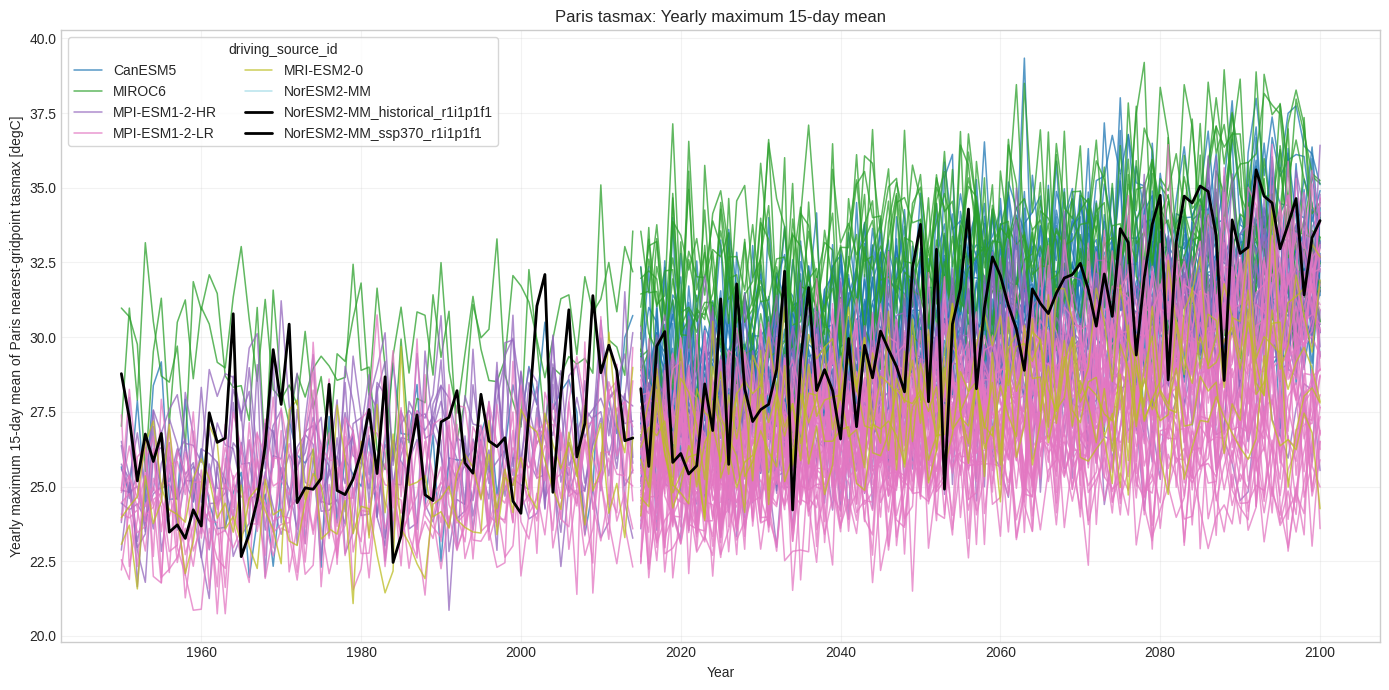

driving_source_id  experiment_id  scenario_group
CanESM5            historical     historical         1
                   ssp245         ssp               20
                   ssp370         ssp                1
                   ssp434         ssp                1
                   ssp460         ssp                2
MIROC6             historical     historical         2
                   ssp126         ssp                3
                   ssp245         ssp                2
                   ssp370         ssp                3
                   ssp434         ssp                1
                   ssp460         ssp                1
                   ssp585         ssp                1
MPI-ESM1-2-HR      historical     historical         8
                   ssp126         ssp                1
                   ssp245         ssp                2
                   ssp370         ssp                9
                   ssp585         ssp                1
MPI-ESM1-2-LR   

In [4]:
driving_source_colors = build_driving_source_colors(metric)

fig, ax = plt.subplots(figsize=(14, 7))
plot_member_ensemble(ax, metric, colors=driving_source_colors)
plot_highlight_member(ax, metric, HIGHLIGHT_MEMBERS)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {metric.title}",
    f"{metric.attrs.get('long_name', metric_name)} [{metric.attrs.get('units', '')}]",
)
save_figure(fig, f"101_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_members", config)
plt.show()

summary.groupby(["driving_source_id", "experiment_id", "scenario_group"]).size().rename("n_files")

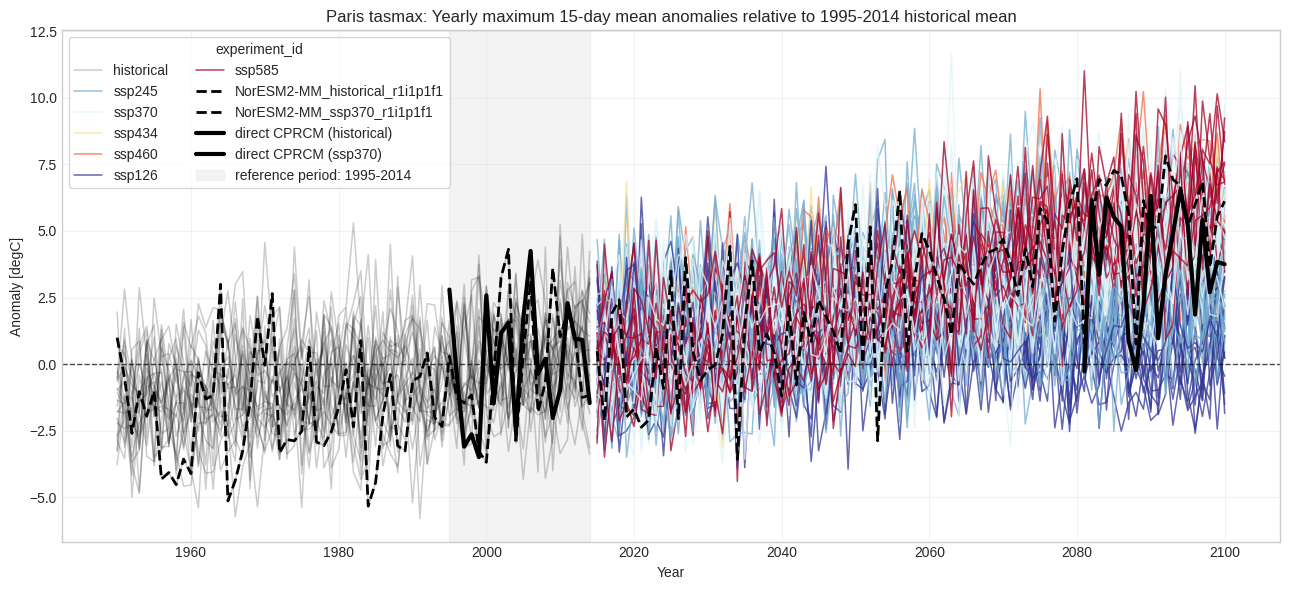

,emulator_reference,cprcm_reference
driving_source_id,,
CanESM5,27.682699,NaN
MIROC6,30.287643,NaN
MPI-ESM1-2-HR,26.644451,NaN
MPI-ESM1-2-LR,25.436863,NaN
MRI-ESM2-0,25.766424,NaN
NorESM2-MM,27.785870,29.59819


In [5]:
ssp_colors = build_experiment_colors(anomaly_metric)

fig, ax = plt.subplots(figsize=(13, 6))
plot_member_ensemble(
    ax,
    anomaly_metric,
    colors=ssp_colors,
    color_coord="experiment_id",
    legend_title="experiment_id",
    alpha_by_color_value={"historical": 0.2},
)
plot_highlight_member(ax, anomaly_metric, HIGHLIGHT_MEMBERS, linestyle="--")
plot_cprcm_anomaly(ax, cprcm_anomaly, color="black", linewidth=3.0)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {cprcm_metric.title} anomalies relative to {REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop} historical mean",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
    legend_title="experiment_id",
)
save_figure(fig, f"102_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_anomalies_emulator_cprcm_eobs", config)
plt.show()

pd.DataFrame({"emulator_reference": historical_reference, "cprcm_reference": cprcm_historical_reference})

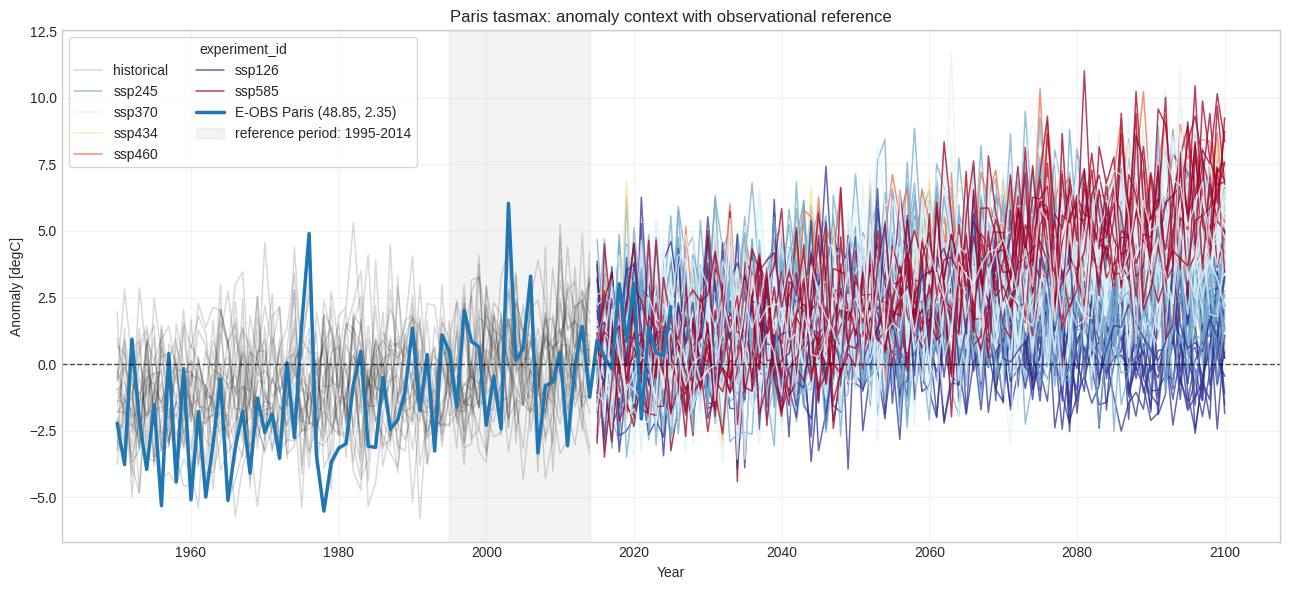

29.30303382873535

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_member_ensemble(
    ax,
    anomaly_metric,
    colors=ssp_colors,
    color_coord="experiment_id",
    legend_title="experiment_id",
    alpha_by_color_value={"historical": 0.15},
)
ax.plot(
    eobs_anomaly.year.values,
    eobs_anomaly.values,
    color="#1f77b4",
    linewidth=2.5,
    label=f"E-OBS {eobs_metric.attrs['location_name']} ({eobs_metric.attrs['selected_lat']:.2f}, {eobs_metric.attrs['selected_lon']:.2f})",
)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: anomaly context with observational reference",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
    legend_title="experiment_id",
)
save_figure(fig, f"103_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_anomalies_with_eobs", config)
plt.show()

eobs_reference.values.item()